# Delhivery Logistics Analytics

### End-to-End Data Analysis Project

**Objective:** Analyze logistics operations, delivery delays, route performance, and operational factors using Python, SQL, and Power BI.

**Dataset:** Delhivery Logistics Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Project 2\delhivery_data.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (144867, 24)


In [136]:
df.head(5)

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,35:36.5,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),21:32.4,...,9/20/2018 4:27,10.435660,14,11,11.9653,1.272727,14,11,11.9653,1.272727
1,training,35:36.5,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),21:32.4,...,9/20/2018 4:17,18.936842,24,20,21.7243,1.200000,10,9,9.7590,1.111111
2,training,35:36.5,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),21:32.4,...,01:19.5,27.637279,40,28,32.5395,1.428571,16,7,10.8152,2.285714
3,training,35:36.5,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),21:32.4,...,9/20/2018 3:39,36.118028,62,40,45.5620,1.550000,21,12,13.0224,1.750000
4,training,35:36.5,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),21:32.4,...,9/20/2018 3:33,39.386040,68,44,54.2181,1.545455,6,5,3.9153,1.200000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  int64  
 12  is_cutoff       

In [9]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

source_name         293
destination_name    261
dtype: int64

In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [13]:
categorical_cols = [
    "data",
    "route_type",
    "trip_uuid",
    "source_center",
    "source_name",
    "destination_center",
    "destination_name"
]

df[categorical_cols].nunique()

data                      2
route_type                2
trip_uuid             14817
source_center          1508
source_name            1498
destination_center     1481
destination_name       1468
dtype: int64

In [15]:
print("Data split:")
print(df["data"].value_counts())

print("\nRoute type:")
print(df["route_type"].value_counts())

Data split:
data
training    104858
test         40009
Name: count, dtype: int64

Route type:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
start_scan_to_end_scan,144867.0,961.262986,1037.012769,20.000000,161.000000,449.000000,1634.000000,7898.000000
cutoff_factor,144867.0,232.926567,344.755577,9.000000,22.000000,66.000000,286.000000,1927.000000
actual_distance_to_destination,144867.0,234.073372,344.990009,9.000045,23.355874,66.126571,286.708875,1927.447705
actual_time,144867.0,416.927527,598.103621,9.000000,51.000000,132.000000,513.000000,4532.000000
osrm_time,144867.0,213.868272,308.011085,6.000000,27.000000,64.000000,257.000000,1686.000000
osrm_distance,144867.0,284.771297,421.119294,9.008200,29.914700,78.525800,343.193250,2326.199100
factor,144867.0,2.120107,1.715421,0.144000,1.604264,1.857143,2.213483,77.387097
segment_actual_time,144867.0,36.196111,53.571158,-244.000000,20.000000,29.000000,40.000000,3051.000000
segment_osrm_time,144867.0,18.507548,14.775960,0.000000,11.000000,17.000000,22.000000,1611.000000
segment_osrm_distance,144867.0,22.829020,17.860660,0.000000,12.070100,23.513000,27.813250,2191.403700


In [19]:
print("Unique trips:", df["trip_uuid"].nunique())
print("Unique route schedules:", df["route_schedule_uuid"].nunique())

print("\nTrips by dataset:")
print(df.groupby("data")["trip_uuid"].nunique())

Unique trips: 14817
Unique route schedules: 1504

Trips by dataset:
data
test         4163
training    10654
Name: trip_uuid, dtype: int64


In [21]:
print("Route type distribution:")
print(df["route_type"].value_counts())

print("\nRoute type percentage:")
print((df["route_type"].value_counts(normalize=True) * 100).round(2))

Route type distribution:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

Route type percentage:
route_type
FTL        68.79
Carting    31.21
Name: proportion, dtype: float64


In [23]:
print("Cutoff status distribution:")
print(df["is_cutoff"].value_counts())

print("\nCutoff status percentage:")
print((df["is_cutoff"].value_counts(normalize=True) * 100).round(2))

Cutoff status distribution:
is_cutoff
True     118749
False     26118
Name: count, dtype: int64

Cutoff status percentage:
is_cutoff
True     81.97
False    18.03
Name: proportion, dtype: float64


In [25]:
print("Unique source centers:", df["source_center"].nunique())
print("Unique destination centers:", df["destination_center"].nunique())

print("\nMissing source names:", df["source_name"].isnull().sum())
print("Missing destination names:", df["destination_name"].isnull().sum())

Unique source centers: 1508
Unique destination centers: 1481

Missing source names: 293
Missing destination names: 261


In [27]:
trip_segment_counts = df.groupby("trip_uuid").size()

print("Minimum segments per trip:", trip_segment_counts.min())
print("Median segments per trip:", trip_segment_counts.median())
print("Average segments per trip:", round(trip_segment_counts.mean(), 2))
print("Maximum segments per trip:", trip_segment_counts.max())

Minimum segments per trip: 1
Median segments per trip: 5.0
Average segments per trip: 9.78
Maximum segments per trip: 101


In [29]:
duplicate_rows = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

Exact duplicate rows: 0


In [31]:
df.dtypes

data                               object
trip_creation_time                 object
route_schedule_uuid                object
route_type                         object
trip_uuid                          object
source_center                      object
source_name                        object
destination_center                 object
destination_name                   object
od_start_time                      object
od_end_time                        object
start_scan_to_end_scan              int64
is_cutoff                            bool
cutoff_factor                       int64
cutoff_timestamp                   object
actual_distance_to_destination    float64
actual_time                         int64
osrm_time                           int64
osrm_distance                     float64
factor                            float64
segment_actual_time                 int64
segment_osrm_time                   int64
segment_osrm_distance             float64
segment_factor                    

In [33]:
time_cols = [
    "trip_creation_time",
    "od_start_time",
    "od_end_time",
    "cutoff_timestamp"
]

for col in time_cols:
    print(f"\n--- {col} ---")
    print(df[col].head(10).tolist())


--- trip_creation_time ---
['35:36.5', '35:36.5', '35:36.5', '35:36.5', '35:36.5', '35:36.5', '35:36.5', '35:36.5', '35:36.5', '35:36.5']

--- od_start_time ---
['21:32.4', '21:32.4', '21:32.4', '21:32.4', '21:32.4', '47:45.2', '47:45.2', '47:45.2', '47:45.2', '47:45.2']

--- od_end_time ---
['47:45.2', '47:45.2', '47:45.2', '47:45.2', '47:45.2', '36:55.6', '36:55.6', '36:55.6', '36:55.6', '36:55.6']

--- cutoff_timestamp ---
['9/20/2018 4:27', '9/20/2018 4:17', '01:19.5', '9/20/2018 3:39', '9/20/2018 3:33', '9/20/2018 6:15', '9/20/2018 5:47', '9/20/2018 5:25', '9/20/2018 5:15', '9/20/2018 4:49']


In [35]:
for col in ["trip_creation_time", "od_start_time", "od_end_time"]:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Sample:", df[col].drop_duplicates().head(10).tolist())


--- trip_creation_time ---
Unique values: 12133
Minimum: 00:00.0
Maximum: 59:59.7
Sample: ['35:36.5', '42:06.0', '42:46.4', '44:19.4', '21:45.1', '26:00.5', '33:48.7', '00:45.7', '16:14.8', '41:42.0']

--- od_start_time ---
Unique values: 18689
Minimum: 00:00.3
Maximum: 59:59.9
Sample: ['21:32.4', '47:45.2', '42:06.0', '42:46.4', '44:19.4', '59:56.1', '22:04.1', '42:55.2', '12:34.5', '26:00.5']

--- od_end_time ---
Unique values: 18675
Minimum: 00:00.1
Maximum: 59:59.9
Sample: ['47:45.2', '36:55.6', '44:28.4', '31:45.4', '59:56.1', '55:58.8', '42:55.2', '12:34.5', '44:42.3', '47:54.2']


In [37]:
cutoff_parsed = pd.to_datetime(
    df["cutoff_timestamp"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

print("Invalid cutoff timestamps:", cutoff_parsed.isna().sum())
print("Minimum timestamp:", cutoff_parsed.min())
print("Maximum timestamp:", cutoff_parsed.max())

Invalid cutoff timestamps: 3429
Minimum timestamp: 2018-09-12 00:10:00
Maximum timestamp: 2018-10-06 23:44:00


In [39]:
invalid_cutoff = df.loc[cutoff_parsed.isna(), "cutoff_timestamp"]

print("Number of invalid values:", len(invalid_cutoff))
print("\nSample invalid values:")
print(invalid_cutoff.head(20).tolist())

print("\nValue patterns:")
print(invalid_cutoff.astype(str).str.len().value_counts().sort_index())

Number of invalid values: 3429

Sample invalid values:
['01:19.5', '12:09.6', '12:09.6', '19:24.2', '27:25.7', '54:06.3', '31:21.6', '04:49.3', '59:09.7', '24:57.9', '24:57.9', '26:37.8', '21:58.2', '02:58.7', '53:43.6', '11:12.8', '29:34.2', '19:57.7', '19:57.7', '21:01.9']

Value patterns:
cutoff_timestamp
7    3429
Name: count, dtype: int64


In [41]:
cutoff_format_check = df.assign(
    cutoff_is_datetime=df["cutoff_timestamp"].str.contains("/")
)

print(pd.crosstab(
    df["data"],
    cutoff_format_check["cutoff_is_datetime"],
    margins=True
))

cutoff_is_datetime  False    True     All
data                                     
test                  448   39561   40009
training             2981  101877  104858
All                  3429  141438  144867


In [43]:
print(pd.crosstab(
    df["is_cutoff"],
    cutoff_format_check["cutoff_is_datetime"],
    margins=True
))

cutoff_is_datetime  False    True     All
is_cutoff                                
False                2841   23277   26118
True                  588  118161  118749
All                  3429  141438  144867


In [45]:
df.loc[
    ~cutoff_format_check["cutoff_is_datetime"],
    [
        "data",
        "is_cutoff",
        "cutoff_factor",
        "cutoff_timestamp",
        "actual_time",
        "osrm_time"
    ]
].head(20)

,data,is_cutoff,cutoff_factor,cutoff_timestamp,actual_time,osrm_time
2,training,True,27,01:19.5,40,28
53,training,True,36,12:09.6,59,28
54,training,False,37,12:09.6,59,28
60,training,False,56,19:24.2,110,60
66,training,False,52,27:25.7,112,67
86,training,False,79,54:06.3,102,67
106,training,False,61,31:21.6,147,54
111,training,False,34,04:49.3,110,43
203,training,False,37,59:09.7,68,28
280,test,True,22,24:57.9,50,28


In [47]:
id_vars = [
    "trip_creation_time",
    "route_schedule_uuid",
    "route_type",
    "source_center",
    "destination_center"
]

for col in id_vars:
    consistency = df.groupby("trip_uuid")[col].nunique()
    print(f"{col}: {((consistency > 1).sum())} trips have multiple values")

trip_creation_time: 0 trips have multiple values
route_schedule_uuid: 0 trips have multiple values
route_type: 0 trips have multiple values
source_center: 5856 trips have multiple values
destination_center: 5855 trips have multiple values


In [49]:
od_leg_counts = df.groupby(
    ["trip_uuid", "od_start_time", "od_end_time"]
).size()

print("Total OD legs:", len(od_leg_counts))
print("Minimum segments per OD leg:", od_leg_counts.min())
print("Median segments per OD leg:", od_leg_counts.median())
print("Average segments per OD leg:", round(od_leg_counts.mean(), 2))
print("Maximum segments per OD leg:", od_leg_counts.max())

Total OD legs: 26369
Minimum segments per OD leg: 1
Median segments per OD leg: 3.0
Average segments per OD leg: 5.49
Maximum segments per OD leg: 81


In [51]:
trip_od_leg_counts = df.groupby(
    ["trip_uuid", "od_start_time", "od_end_time"]
).size().groupby("trip_uuid").size()

print("Minimum OD legs per trip:", trip_od_leg_counts.min())
print("Median OD legs per trip:", trip_od_leg_counts.median())
print("Average OD legs per trip:", round(trip_od_leg_counts.mean(), 2))
print("Maximum OD legs per trip:", trip_od_leg_counts.max())

print("\nOD legs per trip distribution:")
print(trip_od_leg_counts.value_counts().sort_index())

Minimum OD legs per trip: 1
Median OD legs per trip: 1.0
Average OD legs per trip: 1.78
Maximum OD legs per trip: 8

OD legs per trip distribution:
1    8961
2    2716
3    1469
4    1026
5     470
6     113
7      59
8       3
Name: count, dtype: int64


In [53]:
od_group = df.groupby(
    ["trip_uuid", "od_start_time", "od_end_time"]
)

checks = pd.DataFrame({
    "route_type": od_group["route_type"].nunique(),
    "source_center": od_group["source_center"].nunique(),
    "destination_center": od_group["destination_center"].nunique(),
    "start_scan_to_end_scan": od_group["start_scan_to_end_scan"].nunique()
})

print("OD legs with multiple route types:", (checks["route_type"] > 1).sum())
print("OD legs with multiple source centers:", (checks["source_center"] > 1).sum())
print("OD legs with multiple destination centers:", (checks["destination_center"] > 1).sum())
print("OD legs with multiple scan-to-end values:", (checks["start_scan_to_end_scan"] > 1).sum())

OD legs with multiple route types: 0
OD legs with multiple source centers: 0
OD legs with multiple destination centers: 0
OD legs with multiple scan-to-end values: 0


In [55]:
cutoff_consistency = od_group["is_cutoff"].nunique()

print("OD legs with consistent cutoff status:",
      (cutoff_consistency == 1).sum())

print("OD legs with changing cutoff status:",
      (cutoff_consistency > 1).sum())

print("\nCutoff status patterns:")
print(cutoff_consistency.value_counts().sort_index())

OD legs with consistent cutoff status: 1932
OD legs with changing cutoff status: 24437

Cutoff status patterns:
is_cutoff
1     1932
2    24437
Name: count, dtype: int64


In [57]:
cutoff_first = od_group["is_cutoff"].first()
cutoff_last = od_group["is_cutoff"].last()

cutoff_transition = pd.Series(
    np.select(
        [
            (cutoff_first == False) & (cutoff_last == False),
            (cutoff_first == True) & (cutoff_last == True),
            (cutoff_first == True) & (cutoff_last == False),
            (cutoff_first == False) & (cutoff_last == True)
        ],
        [
            "False → False",
            "True → True",
            "True → False",
            "False → True"
        ],
        default="Other"
    )
)

print(cutoff_transition.value_counts())

True → False     24437
False → False     1681
True → True        251
Name: count, dtype: int64


In [60]:
cutoff_factor_consistency = od_group["cutoff_factor"].nunique()

print("OD legs with one cutoff_factor value:",
      (cutoff_factor_consistency == 1).sum())

print("OD legs with changing cutoff_factor:",
      (cutoff_factor_consistency > 1).sum())

print("\nCutoff factor value-count pattern:")
print(cutoff_factor_consistency.value_counts().sort_index())

OD legs with one cutoff_factor value: 2511
OD legs with changing cutoff_factor: 23858

Cutoff factor value-count pattern:
cutoff_factor
1     2511
2     8188
3     5135
4     3161
5     2103
      ... 
76       6
77      70
78      17
79       9
81       1
Name: count, Length: 77, dtype: int64


In [62]:
cutoff_factor_first = od_group["cutoff_factor"].first()
cutoff_factor_last = od_group["cutoff_factor"].last()

cutoff_factor_change = cutoff_factor_last - cutoff_factor_first

print("Average change:", round(cutoff_factor_change.mean(), 2))
print("Minimum change:", cutoff_factor_change.min())
print("Maximum change:", cutoff_factor_change.max())

print("\nChange distribution:")
print(cutoff_factor_change.describe())


Average change: 74.96
Minimum change: -4
Maximum change: 1905

Change distribution:
count    26369.000000
mean        74.963935
std        206.979869
min         -4.000000
25%          6.000000
50%         19.000000
75%         46.000000
max       1905.000000
Name: cutoff_factor, dtype: float64


In [64]:
def first_valid(series):
    values = series.dropna()
    return values.iloc[0] if len(values) > 0 else np.nan


leg_df = (
    df.groupby(
        ["trip_uuid", "od_start_time", "od_end_time"],
        as_index=False
    )
    .agg(
        segment_count=("trip_uuid", "size"),
        actual_time=("actual_time", "max"),
        osrm_time=("osrm_time", "max"),
        actual_distance=("actual_distance_to_destination", "max"),
        osrm_distance=("osrm_distance", "max"),
        start_scan_to_end_scan=("start_scan_to_end_scan", "first"),
        route_type=("route_type", "first"),
        source_center=("source_center", "first"),
        source_name=("source_name", first_valid),
        destination_center=("destination_center", "first"),
        destination_name=("destination_name", first_valid),
        cutoff_initial_status=("is_cutoff", "first"),
        cutoff_final_status=("is_cutoff", "last")
    )
)

leg_df["time_delay"] = leg_df["actual_time"] - leg_df["osrm_time"]

print("OD-leg dataset shape:", leg_df.shape)
print("Unique trips:", leg_df["trip_uuid"].nunique())
print("Duplicate OD legs:", leg_df.duplicated(
    ["trip_uuid", "od_start_time", "od_end_time"]
).sum())

OD-leg dataset shape: (26369, 17)
Unique trips: 14817
Duplicate OD legs: 0


In [67]:
print("Missing values:")
print(leg_df.isnull().sum()[leg_df.isnull().sum() > 0])

print("\nData types:")
print(leg_df.dtypes)

print("\nTime delay summary:")
print(leg_df["time_delay"].describe())

Missing values:
source_name         66
destination_name    81
dtype: int64

Data types:
trip_uuid                  object
od_start_time              object
od_end_time                object
segment_count               int64
actual_time                 int64
osrm_time                   int64
actual_distance           float64
osrm_distance             float64
start_scan_to_end_scan      int64
route_type                 object
source_center              object
source_name                object
destination_center         object
destination_name           object
cutoff_initial_status        bool
cutoff_final_status          bool
time_delay                  int64
dtype: object

Time delay summary:
count    26369.000000
mean       109.617847
std        215.243909
min        -64.000000
25%         21.000000
50%         42.000000
75%         95.000000
max       3137.000000
Name: time_delay, dtype: float64


In [69]:
delay_check = leg_df["actual_time"] - leg_df["osrm_time"]

print("Time delay calculation matches:",
      (leg_df["time_delay"] == delay_check).all())

print("Mismatched rows:",
      (leg_df["time_delay"] != delay_check).sum())

Time delay calculation matches: True
Mismatched rows: 0


In [71]:
trip_metadata_checks = pd.DataFrame({
    "data": df.groupby("trip_uuid")["data"].nunique(),
    "trip_creation_time": df.groupby("trip_uuid")["trip_creation_time"].nunique(),
    "route_schedule_uuid": df.groupby("trip_uuid")["route_schedule_uuid"].nunique(),
    "route_type": df.groupby("trip_uuid")["route_type"].nunique()
})

print("Trips with multiple data values:",
      (trip_metadata_checks["data"] > 1).sum())

print("Trips with multiple trip_creation_time values:",
      (trip_metadata_checks["trip_creation_time"] > 1).sum())

print("Trips with multiple route_schedule_uuid values:",
      (trip_metadata_checks["route_schedule_uuid"] > 1).sum())

print("Trips with multiple route_type values:",
      (trip_metadata_checks["route_type"] > 1).sum())

Trips with multiple data values: 0
Trips with multiple trip_creation_time values: 0
Trips with multiple route_schedule_uuid values: 0
Trips with multiple route_type values: 0


In [73]:
trip_metadata = (
    df.groupby("trip_uuid", as_index=False)
    .agg(
        data=("data", "first"),
        trip_creation_time=("trip_creation_time", "first"),
        route_schedule_uuid=("route_schedule_uuid", "first")
    )
)

leg_df = leg_df.merge(
    trip_metadata,
    on="trip_uuid",
    how="left"
)

print("Updated leg_df shape:", leg_df.shape)
print("\nMissing trip metadata:")
print(leg_df[
    ["data", "trip_creation_time", "route_schedule_uuid"]
].isnull().sum())

Updated leg_df shape: (26369, 20)

Missing trip metadata:
data                   0
trip_creation_time     0
route_schedule_uuid    0
dtype: int64


In [75]:
print("Total columns:", len(leg_df.columns))

print("\nColumns:")
for i, col in enumerate(leg_df.columns, start=1):
    print(f"{i}. {col}")

Total columns: 20

Columns:
1. trip_uuid
2. od_start_time
3. od_end_time
4. segment_count
5. actual_time
6. osrm_time
7. actual_distance
8. osrm_distance
9. start_scan_to_end_scan
10. route_type
11. source_center
12. source_name
13. destination_center
14. destination_name
15. cutoff_initial_status
16. cutoff_final_status
17. time_delay
18. data
19. trip_creation_time
20. route_schedule_uuid


In [77]:
source_mapping_check = (
    df.dropna(subset=["source_name"])
    .groupby("source_center")["source_name"]
    .nunique()
)

destination_mapping_check = (
    df.dropna(subset=["destination_name"])
    .groupby("destination_center")["destination_name"]
    .nunique()
)

print("Source centers with multiple names:",
      (source_mapping_check > 1).sum())

print("Destination centers with multiple names:",
      (destination_mapping_check > 1).sum())

Source centers with multiple names: 0
Destination centers with multiple names: 0


In [79]:
source_map = (
    df.dropna(subset=["source_name"])
    .drop_duplicates("source_center")
    .set_index("source_center")["source_name"]
)

destination_map = (
    df.dropna(subset=["destination_name"])
    .drop_duplicates("destination_center")
    .set_index("destination_center")["destination_name"]
)

leg_df["source_name"] = (
    leg_df["source_name"]
    .fillna(leg_df["source_center"].map(source_map))
)

leg_df["destination_name"] = (
    leg_df["destination_name"]
    .fillna(leg_df["destination_center"].map(destination_map))
)

print("Missing source names:", leg_df["source_name"].isna().sum())
print("Missing destination names:", leg_df["destination_name"].isna().sum())

Missing source names: 66
Missing destination names: 81


In [81]:
remaining_location_gaps = leg_df[
    leg_df["source_name"].isna() | leg_df["destination_name"].isna()
][
    [
        "source_center",
        "source_name",
        "destination_center",
        "destination_name"
    ]
]

print("OD legs with any missing location name:",
      len(remaining_location_gaps))

print("\nMissing source names:",
      remaining_location_gaps["source_name"].isna().sum())

print("Missing destination names:",
      remaining_location_gaps["destination_name"].isna().sum())

remaining_location_gaps.head(10)

OD legs with any missing location name: 146

Missing source names: 66
Missing destination names: 81


,source_center,source_name,destination_center,destination_name
9229,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND122015AAC,NaN
9852,IND577116AAA,NaN,IND577101AAA,Chikmagalur_DC (Karnataka)
9855,IND573103AAA,Arsikere_HsnRdDPP_D (Karnataka),IND577116AAA,NaN
10087,IND504215AAA,Luxettipet_ShivaDPP_D (Telangana),IND505326AAB,NaN
10460,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND122015AAC,NaN
10988,IND509103AAC,NaN,IND518002AAA,Kurnool_AbbasNgr_I (Andhra Pradesh)
11260,IND573103AAA,Arsikere_HsnRdDPP_D (Karnataka),IND577116AAA,NaN
11912,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan)
12282,IND509103AAB,Wanaparthy_VallaDPP_D (Telangana),IND509103AAC,NaN
12283,IND509103AAC,NaN,IND518002AAA,Kurnool_AbbasNgr_I (Andhra Pradesh)


In [83]:
numeric_cols = [
    "segment_count",
    "actual_time",
    "osrm_time",
    "actual_distance",
    "osrm_distance",
    "start_scan_to_end_scan",
    "time_delay"
]

range_check = pd.DataFrame({
    "min": leg_df[numeric_cols].min(),
    "max": leg_df[numeric_cols].max(),
    "negative_count": (leg_df[numeric_cols] < 0).sum(),
    "zero_count": (leg_df[numeric_cols] == 0).sum()
})

range_check

,min,max,negative_count,zero_count
segment_count,1.000000,81.000000,0,0
actual_time,9.000000,4532.000000,0,0
osrm_time,6.000000,1686.000000,0,0
actual_distance,9.001351,1927.447705,0,0
osrm_distance,9.072900,2326.199100,0,0
start_scan_to_end_scan,20.000000,7898.000000,0,0
time_delay,-64.000000,3137.000000,402,63


In [85]:
bins = [-np.inf, 0, 30, 60, 120, np.inf]
labels = [
    "Early",
    "On Time",
    "Moderate Delay",
    "High Delay",
    "Severe Delay"
]

leg_df["delay_category"] = pd.cut(
    leg_df["time_delay"],
    bins=bins,
    labels=labels,
    right=True
)

print(leg_df["delay_category"].value_counts().sort_index())

delay_category
Early              465
On Time           9520
Moderate Delay    6445
High Delay        4766
Severe Delay      5173
Name: count, dtype: int64


In [87]:
print("Category counts:")
print(leg_df["delay_category"].value_counts().sort_index())

print("\nCategory percentages:")
print(
    (leg_df["delay_category"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

print("\nMissing delay categories:",
      leg_df["delay_category"].isna().sum())

Category counts:
delay_category
Early              465
On Time           9520
Moderate Delay    6445
High Delay        4766
Severe Delay      5173
Name: count, dtype: int64

Category percentages:
delay_category
Early              1.76
On Time           36.10
Moderate Delay    24.44
High Delay        18.07
Severe Delay      19.62
Name: proportion, dtype: float64

Missing delay categories: 0


In [89]:
trip_data_check = (
    leg_df.groupby("trip_uuid")["data"]
    .nunique()
)

print("Trips with multiple data splits:",
      (trip_data_check > 1).sum())

print("\nOD legs by dataset:")
print(leg_df["data"].value_counts())

print("\nUnique trips by dataset:")
print(leg_df.groupby("data")["trip_uuid"].nunique())

Trips with multiple data splits: 0

OD legs by dataset:
data
training    18948
test         7421
Name: count, dtype: int64

Unique trips by dataset:
data
test         4163
training    10654
Name: trip_uuid, dtype: int64


In [92]:
trip_order_check = (
    df.groupby("trip_uuid")
    .apply(
        lambda x: x["od_start_time"].is_monotonic_increasing,
        include_groups=False
    )
)

print("Trips with ordered OD start times:",
      trip_order_check.sum())

print("Trips with non-ordered OD start times:",
      (~trip_order_check).sum())

Trips with ordered OD start times: 10594
Trips with non-ordered OD start times: 4223


In [94]:
non_ordered_trip = trip_order_check[~trip_order_check].index[0]

print("Example non-ordered trip:", non_ordered_trip)

df.loc[
    df["trip_uuid"] == non_ordered_trip,
    [
        "trip_uuid",
        "od_start_time",
        "od_end_time",
        "source_center",
        "destination_center",
        "actual_time",
        "osrm_time"
    ]
].head(30)

Example non-ordered trip: trip-153671117375890592


,trip_uuid,od_start_time,od_end_time,source_center,destination_center,actual_time,osrm_time
80300,trip-153671117375890592,12:53.8,52:44.4,IND416012AAA,IND415612AAA,50,19
80301,trip-153671117375890592,12:53.8,52:44.4,IND416012AAA,IND415612AAA,106,42
80302,trip-153671117375890592,12:53.8,52:44.4,IND416012AAA,IND415612AAA,150,59
80303,trip-153671117375890592,12:53.8,52:44.4,IND416012AAA,IND415612AAA,194,79
80304,trip-153671117375890592,12:53.8,52:44.4,IND416012AAA,IND415612AAA,246,91
80305,trip-153671117375890592,52:44.4,10:19.7,IND415612AAA,IND415408AAC,61,33
80306,trip-153671117375890592,52:44.4,10:19.7,IND415612AAA,IND415408AAC,175,72
80307,trip-153671117375890592,52:44.4,10:19.7,IND415612AAA,IND415408AAC,177,74
80308,trip-153671117375890592,52:44.4,10:19.7,IND415612AAA,IND415408AAC,225,88
80309,trip-153671117375890592,10:19.7,32:20.6,IND415408AAC,IND416012AAA,291,48


In [98]:
df_with_index = df.reset_index().rename(columns={"index": "original_row"})

leg_continuity = (
    df_with_index
    .groupby(["trip_uuid", "od_start_time", "od_end_time"])
    .agg(
        first_row=("original_row", "min"),
        last_row=("original_row", "max"),
        row_count=("original_row", "size")
    )
)

leg_continuity["is_contiguous"] = (
    leg_continuity["last_row"] - leg_continuity["first_row"] + 1
    == leg_continuity["row_count"]
)

print("Total OD legs:", len(leg_continuity))
print("Contiguous OD legs:", leg_continuity["is_contiguous"].sum())
print("Non-contiguous OD legs:", (~leg_continuity["is_contiguous"]).sum())

Total OD legs: 26369
Contiguous OD legs: 26369
Non-contiguous OD legs: 0


In [100]:
od_time_check = (
    df.groupby(["trip_uuid", "od_start_time", "od_end_time"])
    .agg(
        actual_time_max=("actual_time", "max"),
        actual_segment_sum=("segment_actual_time", "sum"),
        osrm_time_max=("osrm_time", "max"),
        osrm_segment_sum=("segment_osrm_time", "sum")
    )
)

od_time_check["actual_difference"] = (
    od_time_check["actual_time_max"]
    - od_time_check["actual_segment_sum"]
)

od_time_check["osrm_difference"] = (
    od_time_check["osrm_time_max"]
    - od_time_check["osrm_segment_sum"]
)

print("Actual time difference:")
print(od_time_check["actual_difference"].describe())

print("\nOSRM time difference:")
print(od_time_check["osrm_difference"].describe())

Actual time difference:
count    26369.000000
mean         1.832758
std          3.915069
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         39.000000
Name: actual_difference, dtype: float64

OSRM time difference:
count    26369.000000
mean       -10.607001
std         38.540231
min       -691.000000
25%         -5.000000
50%          0.000000
75%          1.000000
max         15.000000
Name: osrm_difference, dtype: float64


In [102]:
route_performance = (
    leg_df.groupby("route_type")
    .agg(
        od_legs=("trip_uuid", "size"),
        avg_actual_time=("actual_time", "mean"),
        median_actual_time=("actual_time", "median"),
        avg_osrm_time=("osrm_time", "mean"),
        avg_time_delay=("time_delay", "mean"),
        median_time_delay=("time_delay", "median"),
        severe_delay_legs=("delay_category", lambda x: (x == "Severe Delay").sum())
    )
)

route_performance["severe_delay_pct"] = (
    route_performance["severe_delay_legs"]
    / route_performance["od_legs"]
    * 100
)

route_performance.round(2)

,od_legs,avg_actual_time,median_actual_time,avg_osrm_time,avg_time_delay,median_time_delay,severe_delay_legs,severe_delay_pct
route_type,,,,,,,,
Carting,12429,90.17,64.0,34.24,55.92,33.0,1144,9.2
FTL,13940,299.23,119.0,141.74,157.49,58.0,4029,28.9


In [104]:
route_delay_distribution = pd.crosstab(
    leg_df["route_type"],
    leg_df["delay_category"],
    normalize="index"
) * 100

route_delay_distribution.round(2)

delay_category,Early,On Time,Moderate Delay,High Delay,Severe Delay
route_type,,,,,
Carting,1.63,45.25,27.96,15.96,9.2
FTL,1.89,27.95,21.31,19.96,28.9


In [106]:
distance_performance = (
    leg_df.groupby("route_type")
    .agg(
        avg_actual_distance=("actual_distance", "mean"),
        median_actual_distance=("actual_distance", "median"),
        avg_osrm_distance=("osrm_distance", "mean"),
        median_osrm_distance=("osrm_distance", "median"),
        avg_time_delay=("time_delay", "mean"),
        median_time_delay=("time_delay", "median")
    )
)

distance_performance.round(2)

,avg_actual_distance,median_actual_distance,avg_osrm_distance,median_osrm_distance,avg_time_delay,median_time_delay
route_type,,,,,,
Carting,28.99,23.18,38.07,31.07,55.92,33.0
FTL,149.20,55.48,184.06,70.91,157.49,58.0


In [108]:
distance_delay_corr = leg_df[
    ["actual_distance", "time_delay"]
].corr()

print("Correlation between actual distance and time delay:")
print(round(distance_delay_corr.loc["actual_distance", "time_delay"], 4))

Correlation between actual distance and time delay:
0.8387


In [110]:
leg_df["distance_gap"] = (
    leg_df["actual_distance"] - leg_df["osrm_distance"]
)

leg_df["distance_ratio"] = (
    leg_df["actual_distance"] / leg_df["osrm_distance"]
)

trip_segment_count = (
    df.groupby("trip_uuid")
    .size()
    .rename("trip_segment_count")
)

leg_df = leg_df.merge(
    trip_segment_count,
    on="trip_uuid",
    how="left"
)

print("Updated shape:", leg_df.shape)

print("\nNew features:")
print(
    leg_df[
        ["distance_gap", "distance_ratio", "trip_segment_count"]
    ].describe().round(2)
)

Updated shape: (26369, 24)

New features:
       distance_gap  distance_ratio  trip_segment_count
count      26369.00        26369.00            26369.00
mean         -22.71            0.79               11.91
std           47.79            0.12               13.29
min         -469.46            0.10                1.00
25%          -20.49            0.73                4.00
50%           -8.71            0.81                8.00
75%           -4.33            0.87               14.00
max           -0.01            1.00              101.00


In [112]:
leg_df["distance_band"] = pd.cut(
    leg_df["actual_distance"],
    bins=[0, 25, 50, 100, 200, np.inf],
    labels=[
        "0–25 km",
        "25–50 km",
        "50–100 km",
        "100–200 km",
        "200+ km"
    ],
    right=True
)

distance_band_performance = (
    leg_df.groupby("distance_band", observed=False)
    .agg(
        od_legs=("trip_uuid", "size"),
        avg_delay=("time_delay", "mean"),
        median_delay=("time_delay", "median"),
        severe_delay_pct=(
            "delay_category",
            lambda x: (x == "Severe Delay").mean() * 100
        )
    )
)

distance_band_performance.round(2)

,od_legs,avg_delay,median_delay,severe_delay_pct
distance_band,,,,
0–25 km,8454,37.96,23.0,4.74
25–50 km,9017,53.03,33.0,6.19
50–100 km,4640,107.43,69.0,19.85
100–200 km,2002,168.95,125.0,53.45
200+ km,2256,556.19,394.0,98.54


In [114]:
distance_route_performance = (
    leg_df.groupby(
        ["route_type", "distance_band"],
        observed=False
    )
    .agg(
        od_legs=("trip_uuid", "size"),
        avg_delay=("time_delay", "mean"),
        median_delay=("time_delay", "median"),
        severe_delay_pct=(
            "delay_category",
            lambda x: (x == "Severe Delay").mean() * 100
        )
    )
    .reset_index()
)

distance_route_performance.round(2)

,route_type,distance_band,od_legs,avg_delay,median_delay,severe_delay_pct
0,Carting,0–25 km,6676,39.75,24.0,5.47
1,Carting,25–50 km,4460,62.88,38.0,7.98
2,Carting,50–100 km,1199,105.38,80.0,27.77
3,Carting,100–200 km,93,241.83,186.0,95.70
4,Carting,200+ km,1,378.00,378.0,100.00
5,FTL,0–25 km,1778,31.21,21.0,2.02
6,FTL,25–50 km,4557,43.39,29.0,4.43
7,FTL,50–100 km,3441,108.14,65.0,17.09
8,FTL,100–200 km,1909,165.40,122.0,51.39
9,FTL,200+ km,2255,556.27,394.0,98.54


In [116]:
overall_kpis = pd.Series({
    "Total OD Legs": len(leg_df),
    "Total Trips": leg_df["trip_uuid"].nunique(),
    "Avg Delay (min)": leg_df["time_delay"].mean(),
    "Median Delay (min)": leg_df["time_delay"].median(),
    "Severe Delay %": (
        (leg_df["delay_category"] == "Severe Delay").mean() * 100
    ),
    "Avg Actual Time (min)": leg_df["actual_time"].mean(),
    "Avg OSRM Time (min)": leg_df["osrm_time"].mean(),
    "Avg Actual Distance (km)": leg_df["actual_distance"].mean()
})

overall_kpis.round(2)

Total OD Legs               26369.00
Total Trips                 14817.00
Avg Delay (min)               109.62
Median Delay (min)             42.00
Severe Delay %                 19.62
Avg Actual Time (min)         200.69
Avg OSRM Time (min)            91.07
Avg Actual Distance (km)       92.54
dtype: float64

In [118]:
cutoff_performance = (
    leg_df.groupby(
        ["cutoff_initial_status", "cutoff_final_status"]
    )
    .agg(
        od_legs=("trip_uuid", "size"),
        avg_delay=("time_delay", "mean"),
        median_delay=("time_delay", "median"),
        severe_delay_pct=(
            "delay_category",
            lambda x: (x == "Severe Delay").mean() * 100
        )
    )
)

cutoff_performance.round(2)

od_legs  avg_delay  median_delay  \
cutoff_initial_status cutoff_final_status                                     
False                 False                   1681     141.72          33.0   
True                  False                  24437     108.41          43.0   
                      True                     251      12.24           8.0   

                                           severe_delay_pct  
cutoff_initial_status cutoff_final_status                    
False                 False                           28.61  
True                  False                           19.20  
                      True                             0.40

In [120]:
source_performance = (
    leg_df.groupby(["source_center", "source_name"])
    .agg(
        od_legs=("trip_uuid", "size"),
        avg_delay=("time_delay", "mean"),
        median_delay=("time_delay", "median"),
        severe_delay_pct=(
            "delay_category",
            lambda x: (x == "Severe Delay").mean() * 100
        )
    )
    .reset_index()
)

top_source_delay = (
    source_performance[
        source_performance["od_legs"] >= 30
    ]
    .sort_values("avg_delay", ascending=False)
    .head(10)
)

top_source_delay.round(2)

,source_center,source_name,od_legs,avg_delay,median_delay,severe_delay_pct
1352,IND781018AAB,Guwahati_Hub (Assam),90,597.98,119.0,50.00
1304,IND751002AAB,Bhubaneshwar_Hub (Orissa),79,447.86,270.0,82.28
508,IND395023AAA,Surat_HUB (Gujarat),93,442.62,458.0,77.42
8,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),1063,399.32,136.0,54.47
1495,IND854326AAB,Purnia_Central_H_2 (Bihar),70,348.40,112.5,47.14
1440,IND821115AAB,Sasaram_Central_I_2 (Bihar),32,307.81,279.5,59.38
34,IND110064AAA,Delhi_Mayapuri_PC (Delhi),42,276.76,47.0,45.24
1454,IND834002AAB,Ranchi_Hub (Jharkhand),80,273.68,178.0,71.25
1216,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),262,268.18,109.5,42.37
672,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),123,257.50,113.0,48.78


In [122]:
destination_performance = (
    leg_df.groupby(["destination_center", "destination_name"])
    .agg(
        od_legs=("trip_uuid", "size"),
        avg_delay=("time_delay", "mean"),
        median_delay=("time_delay", "median"),
        severe_delay_pct=(
            "delay_category",
            lambda x: (x == "Severe Delay").mean() * 100
        )
    )
    .reset_index()
)

top_destination_delay = (
    destination_performance[
        destination_performance["od_legs"] >= 30
    ]
    .sort_values("avg_delay", ascending=False)
    .head(10)
)

top_destination_delay.round(2)

,destination_center,destination_name,od_legs,avg_delay,median_delay,severe_delay_pct
1284,IND751002AAB,Bhubaneshwar_Hub (Orissa),85,630.95,445.0,80.00
1194,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),219,630.55,569.0,79.45
25,IND110037AAM,Delhi_Airport_H (Delhi),189,477.94,183.0,66.14
1424,IND834002AAB,Ranchi_Hub (Jharkhand),66,471.83,379.5,89.39
1428,IND842001AAA,Muzaffrpur_Bbganj_I (Bihar),158,463.99,532.0,90.51
206,IND211002AAB,Allahabad_Central_H_1 (Uttar Pradesh),52,441.63,170.5,59.62
1410,IND821115AAB,Sasaram_Central_I_2 (Bihar),48,421.02,417.5,60.42
836,IND521225AAB,Vijayawada_Rynapadu_H (Andhra Pradesh),61,405.95,133.0,57.38
662,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),143,348.53,148.0,53.85
335,IND302014AAA,Jaipur_Hub (Rajasthan),96,339.07,191.0,83.33


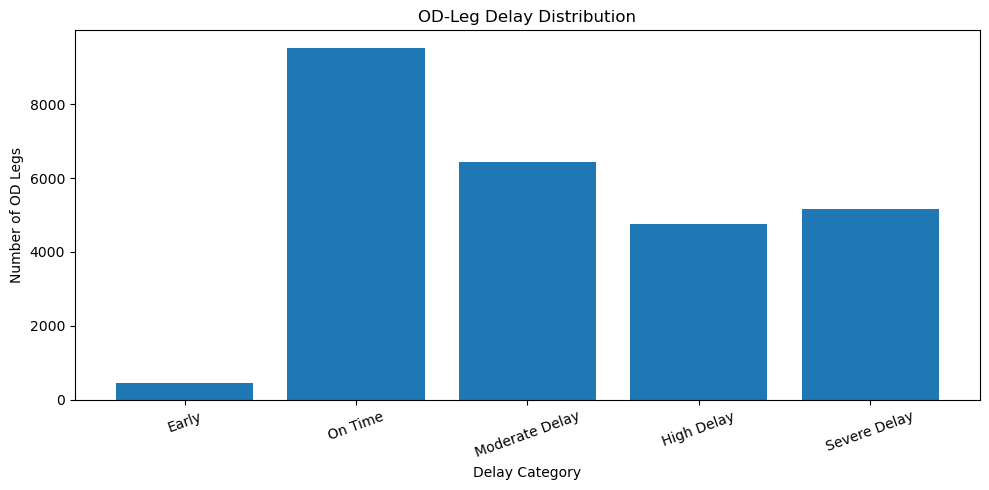

In [124]:
delay_counts = leg_df["delay_category"].value_counts().reindex(
    ["Early", "On Time", "Moderate Delay", "High Delay", "Severe Delay"]
)

plt.figure(figsize=(10, 5))
plt.bar(delay_counts.index, delay_counts.values)

plt.title("OD-Leg Delay Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Number of OD Legs")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

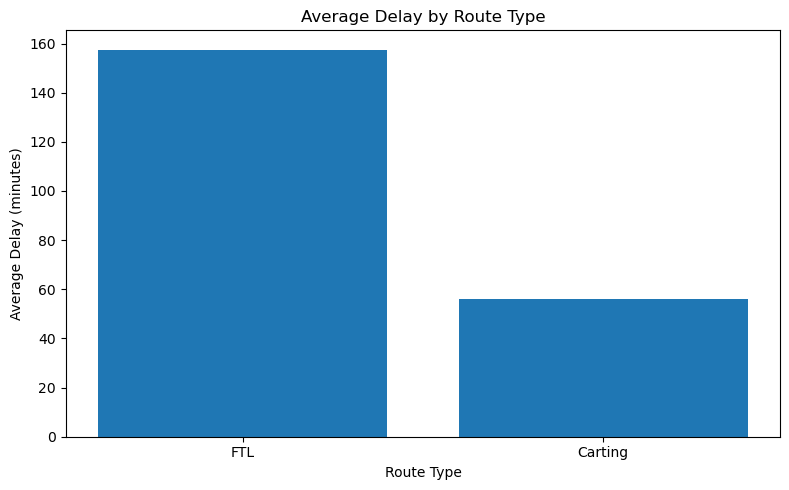

In [126]:
route_delay = (
    leg_df.groupby("route_type")["time_delay"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(route_delay.index, route_delay.values)

plt.title("Average Delay by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Average Delay (minutes)")

plt.tight_layout()
plt.show()

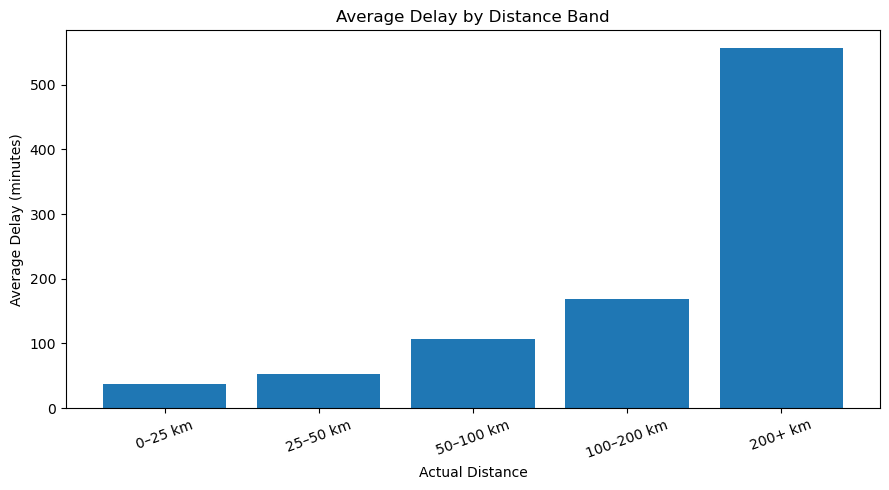

In [128]:
plt.figure(figsize=(9, 5))

plt.bar(
    distance_band_performance.index.astype(str),
    distance_band_performance["avg_delay"]
)

plt.title("Average Delay by Distance Band")
plt.xlabel("Actual Distance")
plt.ylabel("Average Delay (minutes)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

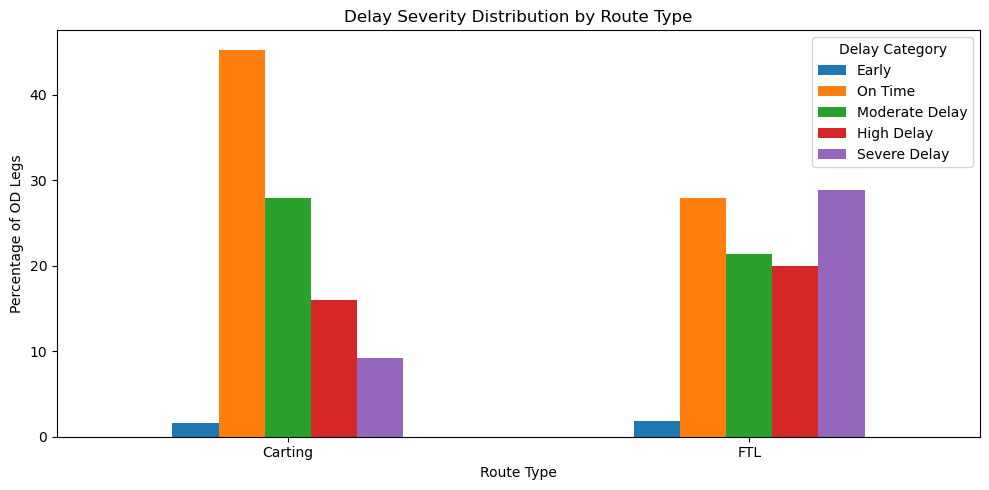

In [130]:
route_delay_pct = pd.crosstab(
    leg_df["route_type"],
    leg_df["delay_category"],
    normalize="index"
) * 100

route_delay_pct = route_delay_pct.reindex(
    columns=[
        "Early",
        "On Time",
        "Moderate Delay",
        "High Delay",
        "Severe Delay"
    ]
)

route_delay_pct.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Delay Severity Distribution by Route Type")
plt.xlabel("Route Type")
plt.ylabel("Percentage of OD Legs")
plt.xticks(rotation=0)
plt.legend(title="Delay Category")

plt.tight_layout()
plt.show()

In [132]:
source_priority = source_performance[
    source_performance["od_legs"] >= 50
].copy()

source_priority["priority_score"] = (
    source_priority["avg_delay"].rank(pct=True) *
    source_priority["severe_delay_pct"].rank(pct=True)
)

top_source_priority = (
    source_priority
    .sort_values("priority_score", ascending=False)
    .head(10)
)

top_source_priority[
    [
        "source_center",
        "source_name",
        "od_legs",
        "avg_delay",
        "severe_delay_pct",
        "priority_score"
    ]
].round(2)

,source_center,source_name,od_legs,avg_delay,severe_delay_pct,priority_score
1304,IND751002AAB,Bhubaneshwar_Hub (Orissa),79,447.86,82.28,0.98
508,IND395023AAA,Surat_HUB (Gujarat),93,442.62,77.42,0.95
1352,IND781018AAB,Guwahati_Hub (Assam),90,597.98,50.00,0.89
1454,IND834002AAB,Ranchi_Hub (Jharkhand),80,273.68,71.25,0.87
8,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),1063,399.32,54.47,0.86
1495,IND854326AAB,Purnia_Central_H_2 (Bihar),70,348.40,47.14,0.80
672,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),123,257.50,48.78,0.77
379,IND313001AAB,Udaipur_Mangri_I (Rajasthan),53,171.66,71.70,0.76
1216,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),262,268.18,42.37,0.73
564,IND411033AAA,Pune_Tathawde_H (Maharashtra),403,185.31,45.91,0.70


In [134]:
output_file = "delhivery_od_leg_analysis.csv"

leg_df.to_csv(output_file, index=False)

print("File exported successfully:", output_file)
print("Rows:", len(leg_df))
print("Columns:", len(leg_df.columns))

File exported successfully: delhivery_od_leg_analysis.csv
Rows: 26369
Columns: 25


In [138]:
print("Final analytical dataset")
print("------------------------")
print("Rows:", leg_df.shape[0])
print("Columns:", leg_df.shape[1])

print("\nColumn list:")
print(leg_df.columns.tolist())

print("\nMissing values:")
print(leg_df.isnull().sum()[leg_df.isnull().sum() > 0])

Final analytical dataset
------------------------
Rows: 26369
Columns: 25

Column list:
['trip_uuid', 'od_start_time', 'od_end_time', 'segment_count', 'actual_time', 'osrm_time', 'actual_distance', 'osrm_distance', 'start_scan_to_end_scan', 'route_type', 'source_center', 'source_name', 'destination_center', 'destination_name', 'cutoff_initial_status', 'cutoff_final_status', 'time_delay', 'data', 'trip_creation_time', 'route_schedule_uuid', 'delay_category', 'distance_gap', 'distance_ratio', 'trip_segment_count', 'distance_band']

Missing values:
source_name         66
destination_name    81
dtype: int64
